## PatchTST - A Transformer Architecture for long-term forecasting for time-series - Training auf dem Datensatz Traffic

Wir gehen in diesem Notebook nicht auf die Details von PatchTST ein, sondern konzentrieren uns auf das Training und die Interpretation der Ergebnisse. 

Die Reihenfolge orientiert sich am **CRISP-DM-Modell**:

1. Geschäftsverständnis
2. Datenverständnis
3. Datenvorbereitung
4. Modeling
5. Evaluation
6. Deployment

Wichtig: CRISP-DM ist kein einmaliger Durchlauf. Feedback aus der Evaluation oder aus dem Fachbereich kann dazu führen, dass wir eine weitere Iteration starten und Annahmen, Daten oder Modellierung anpassen.

## PatchTST - Modell Architektur und Erläuterung der einzelnen Schichten


In [1]:
# Import von Tensorflow
import tensorflow as tf
tf.config.run_functions_eagerly(True)
from tensorflow.keras import layers

In [2]:
import numpy as np
np.random.seed(42) # Wiederholbare Ergebnisse erzeugen.

Die Embedding Schicht unseres Modells:

In [3]:
class PatchTSTEmbedding(layers.Layer):
    def __init__(self, patch_len, stride, d_model):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride
        self.proj = layers.Dense(d_model)

    def call(self, x):
        # x Form: (batch, seq_len, channels)
        batch = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]
        channels = tf.shape(x)[2]

        # 1. Striktes Channel-Independence: Kanäle in die Batch-Dimension verschieben
        # Neuen Form: (batch, channels, seq_len)
        x = tf.transpose(x, perm=[0, 2, 1])
        # Zusammenfassen zu: (batch * channels, seq_len)
        x = tf.reshape(x, (batch * channels, seq_len))

        # 2. Extraktion der Patches mit Stride (Überlappung) mithilfe von Slicing oder tf.signal
        # (Zur Vereinfachung hier via Slicing für überlappende Fenster)
        num_patches = (seq_len - self.patch_len) // self.stride + 1
        
        patches = []
        for i in range(num_patches):
            start = i * self.stride
            end = start + self.patch_len
            patches.append(x[:, start:end])
        
        # Form nach Stack: (num_patches, batch * channels, patch_len)
        x = tf.stack(patches, axis=0)
        # Umformen zu: (batch * channels, num_patches, patch_len)
        x = tf.transpose(x, perm=[1, 0, 2])

        # 3. Lineare Projektion auf die Transformer-Dimension d_model
        # Jedes univariate Patch wird jetzt projiziert
        return self.proj(x)  # Ausgabeform: (batch * channels, num_patche

Die Positional Encoding Schicht:

In [4]:
class PatchTSTPositionalEncoding(layers.Layer):
    def __init__(self, num_patches, d_model):
        super().__init__()
        # Lernbare Gewichte für die Positionen: (Num_Patches, d_model)
        self.pos_embed = self.add_weight(
            name="pos_embed",
            shape=(num_patches, d_model),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
            trainable=True
        )

    def call(self, x):
        # x Form: (Batch * Channels, Num_Patches, d_model)
        # Dank Broadcasting wird das (Num_Patches, d_model) Embedding 
        # automatisch auf alle (Batch * Channels) addiert.
        return x + self.pos_embed

Die Transformer-Schicht unseres Modells:

In [5]:
class PatchTSTTransformerBlock(layers.Layer):
    def __init__(self, d_model, n_heads, dimPT, dropout=0.1):
        super().__init__()
        # Multi-Head Attention Komponente
        self.mha = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model // n_heads)
        
        # Position-wise Feed-Forward Network (FFN) mit GELU
        self.ffn = tf.keras.Sequential([
            layers.Dense(dimPT, activation='gelu'),
            layers.Dropout(dropout),
            layers.Dense(d_model)
        ])
        
        # Layer Normalization (Pre-LN Struktur)
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-5)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-5)
        
        # Dropout für die Residuen-Verbindungen
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        # x Form: (Batch * Channels, Num_Patches, d_model)
        
        # 1. Erster Block: Pre-LN -> Attention -> Dropout -> Residual-Addition
        norm_x1 = self.layernorm1(x)
        attn_output = self.mha(query=norm_x1, value=norm_x1, key=norm_x1, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        x = x + attn_output
        
        # 2. Zweiter Block: Pre-LN -> FFN -> Dropout -> Residual-Addition
        norm_x2 = self.layernorm2(x)
        ffn_output = self.ffn(norm_x2, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        x = x + ffn_output
        
        return x  # Ausgabe-Form bleibt: (Batch * Channels, Num_Patches, d_model)


Die Flatten Head Schicht:

In [6]:
class PatchTSTFlattenHead(layers.Layer):
    def __init__(self, num_patches, d_model, pred_len):
        super().__init__()
        self.pred_len = pred_len
        
        # Lineare Schicht zur Vorhersage der zukünftigen Werte
        # Input-Größe implizit: num_patches * d_model
        self.flatten = layers.Flatten()
        self.linear = layers.Dense(pred_len)

    def call(self, x, batch_size, num_channels):
        # x Form beim Eingang: (Batch * Channels, Num_Patches, d_model)
        
        # 1. Abflachen: (Batch * Channels, Num_Patches * d_model)
        x = self.flatten(x)
        
        # 2. Lineare Projektion auf den Vorhersage-Horizont: (Batch * Channels, pred_len)
        x = self.linear(x)
        
        # 3. Zurückfalten in die originale Kanal-Struktur:
        # Erst trennen: (Batch, Channels, pred_len)
        x = tf.reshape(x, (batch_size, num_channels, self.pred_len))
        
        # Dimensionen zurücktauschen zu: (Batch, pred_len, Channels)
        x = tf.transpose(x, perm=[0, 2, 1])
        
        return x

### Das finale PatchTST Vorhersage Modell

In [7]:
class PatchTSTModel(tf.keras.Model):
    def __init__(self, seq_len, patch_len, stride, d_model, heads, mlp_dim, depth, num_channels, pred_len):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride
        
        # Berechnen der exakten Patch-Anzahl vorab
        self.num_patches = (seq_len - patch_len) // stride + 1
        
        # Schichten initialisieren
        self.embedding = PatchTSTEmbedding(patch_len=patch_len, stride=stride, d_model=d_model)
        self.pos_encoding = PatchTSTPositionalEncoding(num_patches=self.num_patches, d_model=d_model)
        
        self.encoder_layers = [
            PatchTSTTransformerBlock(d_model, heads, mlp_dim) 
            for _ in range(depth)
        ]
        
        self.head = PatchTSTFlattenHead(num_patches=self.num_patches, d_model=d_model, pred_len=pred_len)

    def call(self, inputs, training=False):
        # inputs Form: (Batch, seq_len, Channels)
        batch_size = tf.shape(inputs)[0]
        num_channels = tf.shape(inputs)[2]
        
        # 1. Patching & Embedding -> (Batch * Channels, Num_Patches, d_model)
        x = self.embedding(inputs)
        
        # 2. Positional Encoding addieren
        x = self.pos_encoding(x)
        
        # 3. Durch die Transformer-Blöcke schleifen
        for transformer_block in self.encoder_layers:
            x = transformer_block(x, training=training)
            
        # 4. Flatten-Head: Zurückrechnen auf die Ziel-Kanäle -> (Batch, pred_len, Channels)
        outputs = self.head(x, batch_size=batch_size, num_channels=num_channels)
        
        return outputs

### Use Case aus dem OriginalPaper nachstellen und das PatchTST Vorhersage Modell nutzen

### Das Vorhersage-Modell PatchTST auf den Traffic Datensatz angewendet.


Wir trainieren das PatchTST-Prediction-Modell auf dem  traffic-Datensatz. 
Das übergeordnete Ziel ist das langfristige multivariate Verkehrsaufkommen (Long-Term Time Series Forecasting). Wir nutzen im Folgenden ein Vorhersagezeitraum von 720  was 30 Tagen entspricht.

Jedes einzelne Feature steht für die Spurbelegungsrate (einen Wert zwischen 0 und 1). Ein Wert von 0 bedeutet komplett freie Fahrt, während 1 einen extremen Stau (vollständig belegte Straße) signalisiert.
Jede der 862 Spalten im Datensatz entspricht einem fest installierten Verkehrssensor (Induktionsschleife im Asphalt) an einem bestimmten Autobahnabschnitt in San Francisco.

Im Traffic-Datensatz repräsentiert die OT-Spalte die Spurbelegungsrate (Occupancy Rate) des allerletzten (862.) Verkehrssensors in der Region San Francisco.

Wir nutzen für unseren Anwendungsfall nur die ersten 25 Spuren, um die Dauer der Ausführung des Notebooks im Rahmen zu halten.

Schritt 1: Hyperparameter definieren

In [8]:
import warnings

BATCH_SIZE = 16
SEQ_LEN = 720      # Historische Schauzeit (Lookback-Window)
CHANNELS = 25       # Anzahl paralleler Features/Variablen (in unserem Fall Verkehrssensoren)
PRED_LEN = 96      # Vorhersagehorizont (Zukunft)

PATCH_LEN = 16     # Länge eines einzelnen Patches
STRIDE = 8         # Schrittweite (50% Überlappung)
D_MODEL = 128      # Transformer Embedding-Dimension
N_HEADS = 16        # Multi-Head Attention Köpfe
D_FF = 256         # Feed-Forward Dimension im Transformer
NUM_LAYERS = 3     # Anzahl der Transformer-Blöcke 

Schritt 2: Orginale Daten laden und skalieren

In [9]:
import pandas as pd

# Der Traffic Datensatz kann hier heruntergeladen werden: 
# https://drive.google.com/drive/folders/1ZOYpTUa82_jCcxIdTmyr0LXQfvaM9vIy

# 1. Load the CSV file into a DataFrame
# Es wird erwartet, dass das traffic csv im Unterordner dataset liegt.
df = pd.read_csv('dataset/traffic.csv', nrows=0)
print("Datei gefunden.")

# 2. Die Uhrzeitspalte entfernen:
all_columns = df.columns.tolist()
columns_to_keep = all_columns[1:26]
print(columns_to_keep)

# 3. Den echten Datensatz nur mit diesen Spalten laden
df = pd.read_csv('dataset/traffic.csv', usecols=columns_to_keep)
print("Spezifische Features erfolgreich eingelesen.")


Datei gefunden.
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24']
Spezifische Features erfolgreich eingelesen.


In [10]:
import numpy as np

# Datenumwandeln in ein Numpy Array damit unser Modell damit arbeiten kann.
traffic_data = df.to_numpy(dtype='float32')
#np.stack([columns_to_keep], axis=-1).astype(np.float32)
print("--- CSV DATEN GELADEN ---")
print(f"Form des ursprünglichen Arrays: {traffic_data.shape} -> (Zeitschritte, 25 Kanäle)")

--- CSV DATEN GELADEN ---
Form des ursprünglichen Arrays: (17544, 25) -> (Zeitschritte, 25 Kanäle)


In [11]:
# Den Index für die Trennung berechnen (erste 80%)
split_idx = int(len(traffic_data) * 0.8)

# Daten in zwei separate Zeitreihen-Blöcke schneiden
traffic_train_raw = traffic_data[:split_idx]
traffic_test_raw = traffic_data[split_idx:]

print(f"Zeilen für Training:       {len(traffic_train_raw)}")
print(f"Zeilen für Test/Validierung: {len(traffic_test_raw)}\n")

Zeilen für Training:       14035
Zeilen für Test/Validierung: 3509



In [12]:
#Skalierung der Trainingsdaten

# Mittelwert & Std NUR vom Training berechnen!
means = np.mean(traffic_train_raw, axis=0)
stds = np.std(traffic_train_raw, axis=0)
stds = np.where(stds == 0, 1.0, stds)

# BEIDE Blöcke mit den identischen Train-Parametern skalieren
traffic_train_scaled = (traffic_train_raw - means) / stds
traffic_test_scaled = (traffic_test_raw - means) / stds

print("Daten skaliert")

Daten skaliert


Schritt 3: Batch- Aufteilung (Vorhersage Windows erstellen) nachdem die Daten skaliert sind

In [13]:
SEQ_LEN = 512
PRED_LEN = 96
STEP_SIZE = 16 # Schrittweite für die Fenster-Verschiebung

def create_windows(data_sequence):
    X, Y = [], []
    # Loop läuft so lange, wie ein volles Fenster (History + Zukunft) hineinpasst
    for i in range(0, len(data_sequence) - SEQ_LEN - PRED_LEN, STEP_SIZE):
        X.append(data_sequence[i : i + SEQ_LEN])
        Y.append(data_sequence[i + SEQ_LEN : i + SEQ_LEN + PRED_LEN])
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

# Fenster für beide Datensätze unabhängig generieren
X_train, Y_train = create_windows(traffic_train_scaled)
X_val, Y_val = create_windows(traffic_test_scaled)

print("--- FINALE PATCHTST DIMENSIONEN ---")
print(f"X_train (Train Inputs):  {X_train.shape} -> (Batches, {SEQ_LEN}, 25)")
print(f"Y_train (Train Targets): {Y_train.shape} -> (Batches, {PRED_LEN}, 25)")
print(f"X_val   (Test Inputs):   {X_val.shape}")

--- FINALE PATCHTST DIMENSIONEN ---
X_train (Train Inputs):  (840, 512, 25) -> (Batches, 512, 25)
Y_train (Train Targets): (840, 96, 25) -> (Batches, 96, 25)
X_val   (Test Inputs):   (182, 512, 25)


Schritt 4: Vorhersage-PatchTST-Modell instanziieren und testen

In [14]:
# Instanziierung des zuvor definierten Gesamtmodells
model = PatchTSTModel(
    seq_len=SEQ_LEN,
    patch_len=PATCH_LEN,
    stride=STRIDE,
    d_model=D_MODEL,
    heads=N_HEADS,
    mlp_dim=D_FF,
    depth=NUM_LAYERS,
    num_channels=CHANNELS,
    pred_len=PRED_LEN
)

# Test-Vorhersage ohne Training (Forward Pass)
predictions = model(X_train, training=False)

print("--- Dimension des Ausgabelayers prüfen: ---")
print(f"Dimension des Ausgabenlayer:     {predictions.shape} -> Sollte exakt Y_train entsprechen!\n")


--- Dimension des Ausgabelayers prüfen: ---
Dimension des Ausgabenlayer:     (840, 96, 25) -> Sollte exakt Y_train entsprechen!



Schritt 5: MODELL wird Kompiliert und nutzt hierbei den Optimizer ADAM und die Lossfunktion MSE

In [15]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae']
)

warnings.filterwarnings("ignore")
print("--- TRAINING über 100 Durchläufe---")
# Training des Modells über 100 Durchläufe
history = model.fit(X_train, Y_train, epochs=100, batch_size=BATCH_SIZE, verbose=1)
print("\n✔ Modell Test erfolgreich, Dimensionen des Modells passen.")

--- TRAINING über 100 Durchläufe---
Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - loss: 1.9727 - mae: 1.0811
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - loss: 1.0075 - mae: 0.7713
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - loss: 0.7416 - mae: 0.6497
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - loss: 0.6000 - mae: 0.5737
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - loss: 0.5144 - mae: 0.5213
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - loss: 0.4595 - mae: 0.4845
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - loss: 0.4210 - mae: 0.4563
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - loss: 0.3928 - mae: 0.4348
Epoch 9/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - loss: 0.3723 - mae: 0.4177
Epoch 10/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - loss: 0.3541 - mae: 0.4027
Epoch 11/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - loss: 0.3393 - mae: 0.3893
Epoch 12/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - loss: 0.3289 - mae: 0.3796
E

Schritt 6: (optional) Modell lokal speichern

In [16]:
#model.save("patchtstPredModel_complete_model_traffic.keras")
#print("Modell erfolgreich gespeichert!")

Schritt 7: Vorhersage-Methode und Vorhersage ausführen.

In [17]:
def predict_supervised_forecasting(model, x_data):
    """
    Führt die Zukunftsvorhersage (Forecasting) für Supervised PatchTST aus.
    Schaltet den Trainingsmodus aus und liefert die finalen Vorhersagen.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # 1. Daten in Tensor umwandeln
        x_tensor = tf.convert_to_tensor(x_data, dtype=tf.float32)
        
        # 2. Forward Pass im Evaluations-Modus (training=False)
        # Das Supervised-Modell liefert hier die Vorhersage für die Zukunft
        predictions = model(x_tensor, training=False)
        
        # Falls das Modell ein komplexes Ausgabe-Objekt liefert (z.B. bei HuggingFace Modellen),
        # extrahieren wir die reinen Vorhersage-Tensoren:
        if hasattr(predictions, 'prediction_outputs'):
            predictions = predictions.prediction_outputs
        elif hasattr(predictions, 'logits'):
            predictions = predictions.logits
            
        return np.array(predictions, dtype=np.float32)

# --- VORHERSAGE AUSFÜHREN ---
# Wir übergeben die historischen Testdaten (X_val)
predictions_forecast = predict_supervised_forecasting(model, X_val)

# --- DIMENSIONEN VERGLEICHEN ---
print("--- FORECASTING-Dimensionen prüfen ---")
print(f"Eingabe (Historie) X_val:  {X_val.shape}  -> (Batch, Seq_Len, Channels)")
print(f"Modell-Vorhersage:          {predictions_forecast.shape}  -> Sollte (Batch, Pred_Len, Channels) sein")
print(f"Echte Zukunft Y_val:        {Y_val.shape}  -> (Batch, Pred_Len, Channels)")


--- FORECASTING-Dimensionen prüfen ---
Eingabe (Historie) X_val:  (182, 512, 25)  -> (Batch, Seq_Len, Channels)
Modell-Vorhersage:          (182, 96, 25)  -> Sollte (Batch, Pred_Len, Channels) sein
Echte Zukunft Y_val:        (182, 96, 25)  -> (Batch, Pred_Len, Channels)


Schritt 10: (optional): Vorhersage visualisieren

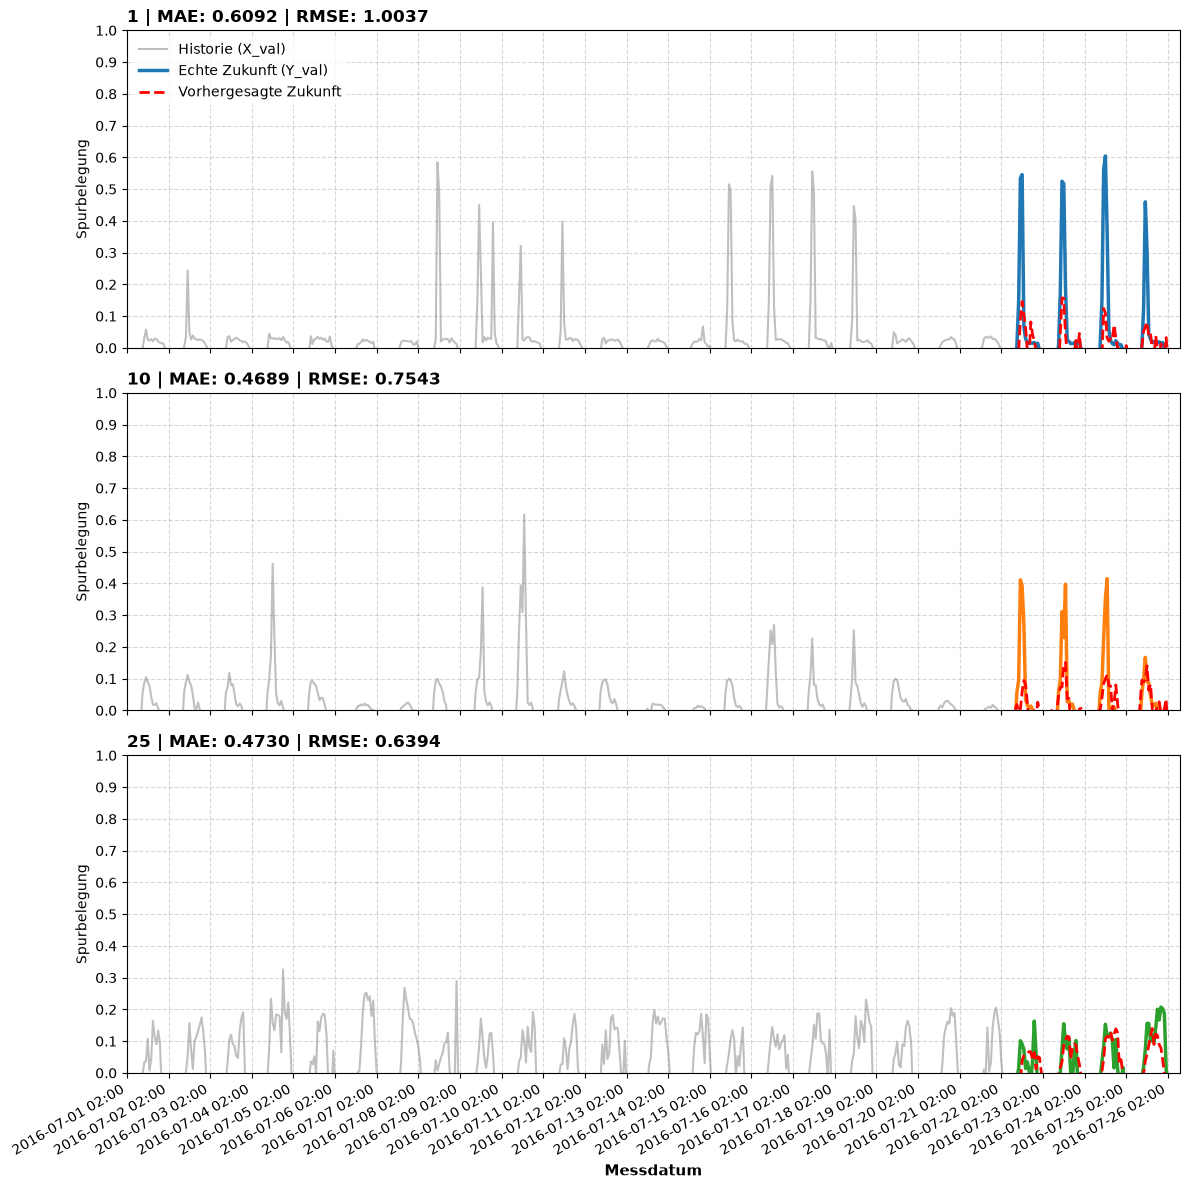

In [ ]:
#Vorhersage visualisieren

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import warnings

def plot_forecasting_results_with_metrics(X_val, Y_val, predictions, sample_idx=0):
    """
    Plottet Historie, echte Zukunft und Vorhersage für 3 Spuren.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        seq_len = X_val.shape[1]
        pred_len = Y_val.shape[1]
        complete = seq_len + pred_len

        start_date = pd.to_datetime("2016-07-01 02:00:00")
        
        full_time_range = pd.date_range(start=start_date, periods=complete, freq='h')
        
        # Zeitachsen für die Visualisierung aufbauen
        
        time_history = full_time_range[:seq_len]
        time_future = full_time_range[seq_len:]
        
        fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
        channel_names = ["1","10", "25"]
        colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
        
        # Die oben definierten 3 Kanäle plotten
        for ch in range(3):
            ax = axes[ch]
            
            # Reale Werte und Vorhersagen für den aktuellen Kanal extrahieren (über den gesamten Val-Satz für stabile Metriken)
            y_true_all = Y_val[:, :, ch]
            y_pred_all = predictions[:, :, ch]
            
            # Metriken berechnen (MAE und RMSE für diesen Kanal über alle Samples)
            mae = np.mean(np.abs(y_true_all - y_pred_all))
            rmse = np.sqrt(np.mean((y_true_all - y_pred_all) ** 2))
            
            # --- 1. HISTORIE PLOTTEN (X_val) ---
            ax.plot(time_history, X_val[sample_idx, :, ch] / 10, 
                    label="Historie (X_val)", color="gray", alpha=0.5)
            
            # --- 2. ECHTE ZUKUNFT PLOTTEN (Y_val) ---
            ax.plot(time_future, Y_val[sample_idx, :, ch] / 10, 
                    label="Echte Zukunft (Y_val)", color=colors[ch], linewidth=2.5)
            
            # --- 3. VORHERSAGE PLOTTEN ---
            ax.plot(time_future, predictions[sample_idx, :, ch] / 10, 
                    label="Vorhergesagte Zukunft", color="red", linestyle="--", linewidth=2)
            
            # --- DESIGN & LABELS  ---
            ax.set_ylabel("Spurbelegung", fontsize=10)
            ax.set_yticks(np.arange(0, 1.1, 0.1))
            ax.set_ylim(0, 1)
            ax.grid(True, linestyle="--", alpha=0.5)
            
            # Titel mit dynamischen Metriken versehen
            ax.set_title(f"{channel_names[ch]} | MAE: {mae:.4f} | RMSE: {rmse:.4f}", 
                         fontsize=12, fontweight="bold", loc="left")
            
            if ch == 0:
                ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")

       # axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=24)) 
        axes[-1].set_xlim(time_history[0], time_future[-1])
        exact_ticks = pd.date_range(start=time_history[0], end=time_future[-1], freq='24h')
        axes[-1].set_xticks(exact_ticks)

        # Format des Datums: "Jahr-Monat-Tag Stunde:Minute" (z.B. 2016-07-01 02:00)
        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
        
        # Rotieren der X-Achsen-Beschriftung, damit sich die Datumsangaben nicht überschneiden
        plt.setp(axes[-1].get_xticklabels(), rotation=30, ha="right")        
        axes[-1].set_xlabel("Messdatum", fontsize=11, fontweight="bold")
        plt.tight_layout()
        plt.show()

# --- PLOT AUSFÜHREN ---
# Nutze die Methode mit deinen bestehenden Arrays
plot_forecasting_results_with_metrics(X_val, Y_val, predictions_forecast, sample_idx=0)